In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:
df = pd.read_csv("smart_cart.csv")

In [123]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [124]:
df.shape

(2240, 22)

In [125]:
df.info
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

# 1. Handle Missing Values

In [126]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [127]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Feature Engineering

In [128]:
# more meaningfull column me convert karna

# AGE
df["Age"]=2026-df["Year_Birth"]

In [129]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [130]:
# customer joining date

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] =(reference_date -df["Dt_Customer"]).dt.days

In [131]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [132]:
# Spending

df["Total_Spending"] = df["MntWines"]+df["MntFruits"]+df["MntSweetProducts"]+df["MntMeatProducts"]+df["MntFishProducts"] +df["MntGoldProds"]

In [133]:
# Chlidern
df["Total_childern"] = df["Kidhome"] +df["Teenhome"]

In [134]:
# Education
df["Education"].value_counts()

# Undergraduate, Graduate,Postgraduate 

df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate", "2n Cycle":"Undergraduate",
    "Graduation" : "Graduate", "PhD" : "Postgraduate","Master" :"Postgraduate"
})

In [135]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [136]:
# Marital Status
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [137]:
df["Living_with"] = df["Marital_Status"].replace({
    "Married " : "Partner", "Together ":"Partner",
    "Single" : "Alone", "Divorced " : "Alone","Widow" :"Alone",
    "Absurd" : "Alone", "YOLO": "Alone"
})

In [138]:
df["Living_with"].value_counts()

Living_with
Married     864
Together    580
Alone       564
Divorced    232
Name: count, dtype: int64

# Drop Columns

In [139]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_childern,Living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Together
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Together
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Married


In [140]:
cols =["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome","Dt_Customer"]

spending_cols=["MntWines", "MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop = cols+ spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [141]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_childern,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Together
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Together
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Married


# Outliers

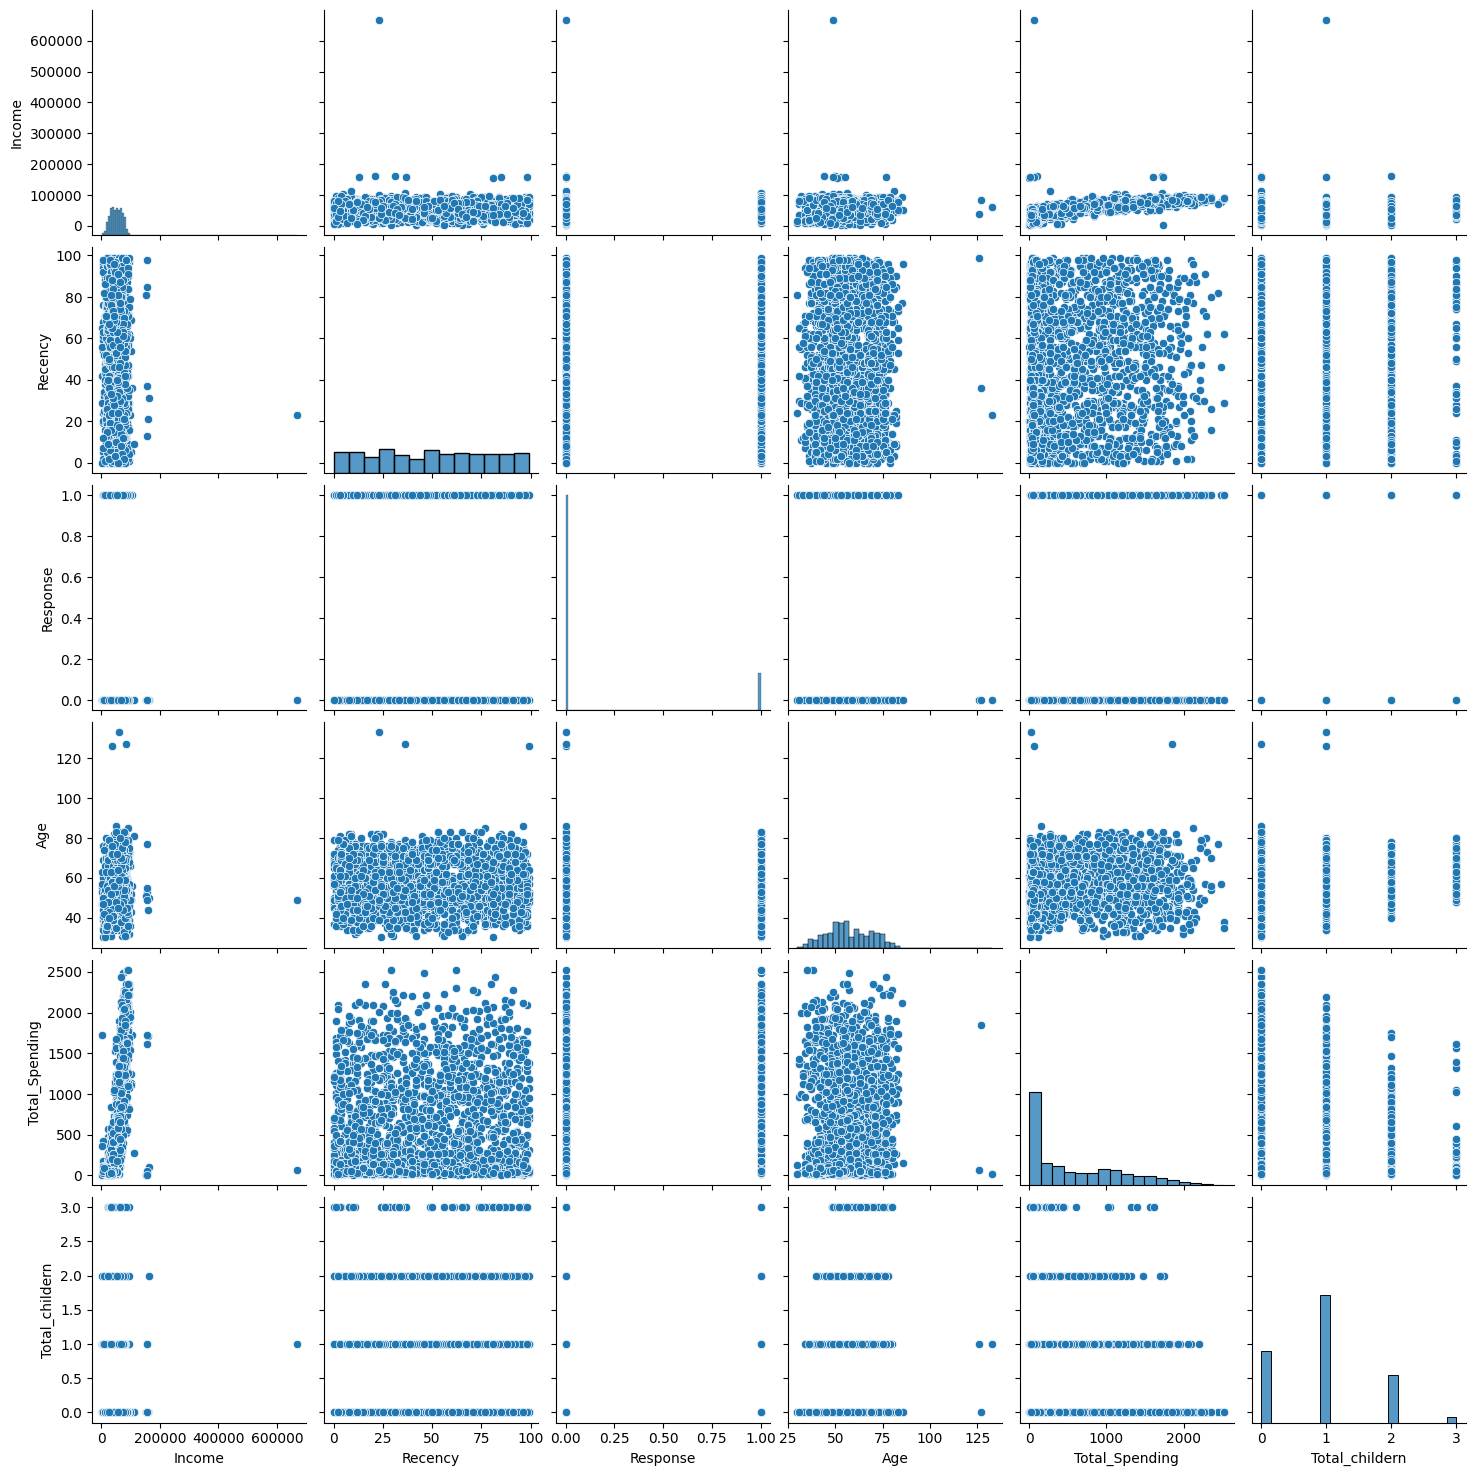

In [142]:
cols =["Income", "Recency", "Response", "Age", "Total_Spending", "Total_childern"]

# relative plots of some features - pair plots

sns.pairplot(df_cleaned[cols])

In [143]:
# RemoveOutliers
print("Data size with outliers", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]<600_000)]

print("Data size without outliers:", len(df_cleaned))

Data size with outliers 2240
Data size without outliers: 2236


# Heatmap

In [144]:
corr = df_cleaned.corr(numeric_only = True)

<Axes: >

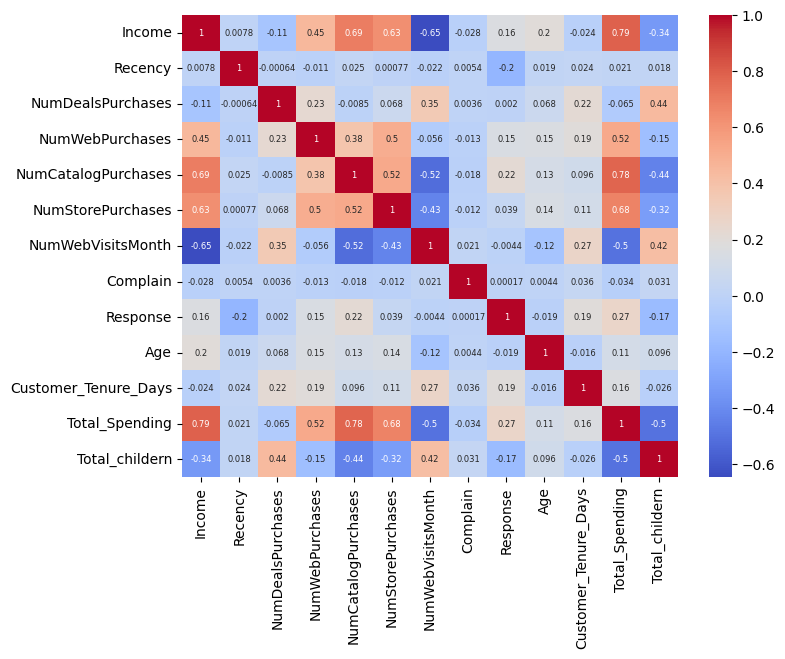

In [145]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot = True,
    annot_kws={"size": 6},
    cmap= "coolwarm"
)

In [146]:
df_cleaned.shape

(2236, 15)

# Encoding

In [147]:
from sklearn.preprocessing import OneHotEncoder

In [149]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_with"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [150]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [151]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)

In [152]:
df_encoded.shape

(2236, 20)

In [153]:
from sklearn.preprocessing import StandardScaler

In [154]:
x = df_encoded

In [155]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Visualize

In [156]:
x_scaled.shape

(2236, 20)

In [157]:
# 2D

from sklearn.decomposition import PCA

In [158]:
pca = PCA(n_components=2)

x_pca = pca.fit_transform(x_scaled)

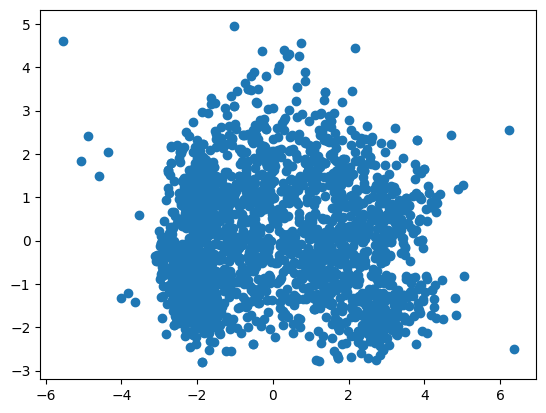

In [159]:
# plot

plt.scatter(x_pca[:,0], x_pca[:,1])

In [160]:
pca.explained_variance_ratio_

array([0.20842786, 0.09402821])